In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'  # For sharper figures, but it takes more time
import matplotlib.cm as cm
import multiprocessing as mp
import scipy as sp
import time
from datetime import datetime

# LISA modules
from lisatools.utils.constants import *
from lisatools.sensitivity  import AE1SensitivityMatrix
from bbhx.waveformbuild import BBHWaveformFD

# Immports for generating simulated LISA data
import noise_generation as noise_generation
from tools.LISASimulator import LISASimulator
from tools.likelihood import get_dh, get_hh
import tools.likelihood as likelihood

# Imports for MCMC
from tools.save_and_load_DE import load_de_results
from tools.time_freq_likelihood import TimeFreqLikelihood
from eryn.ensemble import EnsembleSampler
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.state import State
from scipy.stats import truncnorm
from copy import deepcopy
# Imports for plotting
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import pandas as pd
import corner
import pickle

param_labels = [
    r"$M_T \, [\mathrm{M_\odot}]$",
    r"$q$",
    r"$a_1$",
    r"$a_2$",
    r"$d_L \, [\mathrm{Gpc}]$",
    r"$\phi_{\mathrm{ref}}$",
    r"$\cos(\iota)$",
    r"$\lambda$",
    r"$\sin(\beta)$",
    r"$\psi$",
    r"$t_{\mathrm{c}} \, [\mathrm{s}]$"
]
from tools.MBHB_differential_evolution import MBHB_finder_time_frequency, MBHB_finder_lisatools, MBHB_finder_frequency_domain, transform_bbhx_to_parameters, transform_parameters_to_bbhx

from matplotlib import rc
rc('font', **{
'family': 'serif',
'serif': ['Computer Modern Roman'],
'size' : 16
})
rc('text', usetex=True)

import matplotlib.pyplot as plt

# customized settings
plot_parameter = { # 'backend': 'ps',
"font.family": "DeJavu Serif",
"font.serif": "Times",
"font.size": 16,
"mathtext.fontset": "cm",
"axes.labelsize": "medium",
"axes.titlesize": "medium",
"legend.fontsize": "medium",
"xtick.labelsize": "medium",
"ytick.labelsize": "medium",
"grid.color": "k",
"grid.linestyle": ":",
"grid.linewidth": 0.5,
"savefig.dpi": 150,
}

# tell matplotlib about your param_plots
plt.rcParams.update(plot_parameter)
# set nice figure sizes
fig_width_pt = 1.5*464.0 # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.0) - 1.0) / 2.0 # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1.0 / 72.27 # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt # width in inches
fig_height = fig_width * ratio # height in inches
fig_size = [fig_width, fig_height]
fig_size_squared = [fig_width, fig_width]
plt.rcParams.update({"figure.figsize": fig_size})
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
 

### Create an aitoff projection map and plot on the sky
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import fits
from ligo.skymap import plot, kde, postprocess, io
import healpy as hp

No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.


/opt/anaconda3/envs/lisa_env/lib/python3.12/site-packages/igwn_ligolw/lsctables.py:57: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
Tobs = 1.5*YRSID_SI/12
dt = 5.
include_T_channel = False

wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=False)
sim = LISASimulator(Tobs=Tobs, dt=dt, wave_gen=wave_gen, include_T_channel=include_T_channel)

m1 = 2e5
m2 = 1e5
a1 = 0.2
a2 = 0.4
dist = 6.6 * PC_SI * 1e9
phi_ref = 0.80 #np.pi/2
f_ref = 0.0
inc = 0.224
lam = 1.51
beta = -0.17
psi = 1.37
t_ref = Tobs - (24*60*60)
parameters = np.array([m1, m2, a1, a2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref])
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]
waveform_kwargs = dict(length=1024, direct=False, fill=True, squeeze=False, modes=modes)

data_t, data_f, f_array, t_array, sens_mat = sim(seed = 42, parameters=parameters, waveform_kwargs=waveform_kwargs)
waveform_kwargs.update(freqs=f_array)

print(f"SNR of the Signal: {sim.SNR_optimal()[0]}")

hours_before_merger = 14
time_before_merger = hours_before_merger*60*60
cutoff_time = t_ref - time_before_merger
width_of_tref_prior = 20
max_time = t_ref + (width_of_tref_prior - hours_before_merger)*60*60
nperseg = 1414

nwalkers = 24
ntemps = 4
ndims = 11
nleaves_max = 1
nsteps = 2000
perturb_frac = 0.02

analysis = TimeFreqLikelihood(data_t=data_t, wave_gen=wave_gen, nperseg=nperseg)
analysis.pre_merger(time_before_merger=time_before_merger, t_ref=t_ref, t_array=t_array)
analysis.get_stft_of_data()
analysis.pre_merger_SNR()

injection_parameters = np.array([m1+m2, m2/m1, a1, a2, dist / (PC_SI * 1e9), phi_ref, np.cos(inc), lam, np.sin(beta), psi, t_ref-cutoff_time])

SNR of the Signal: 2240.644732601064
181.48219636999357


/opt/anaconda3/envs/lisa_env/lib/python3.12/site-packages/astropy/visualization/wcsaxes/core.py:258: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = super().contour(*args, **kwargs)


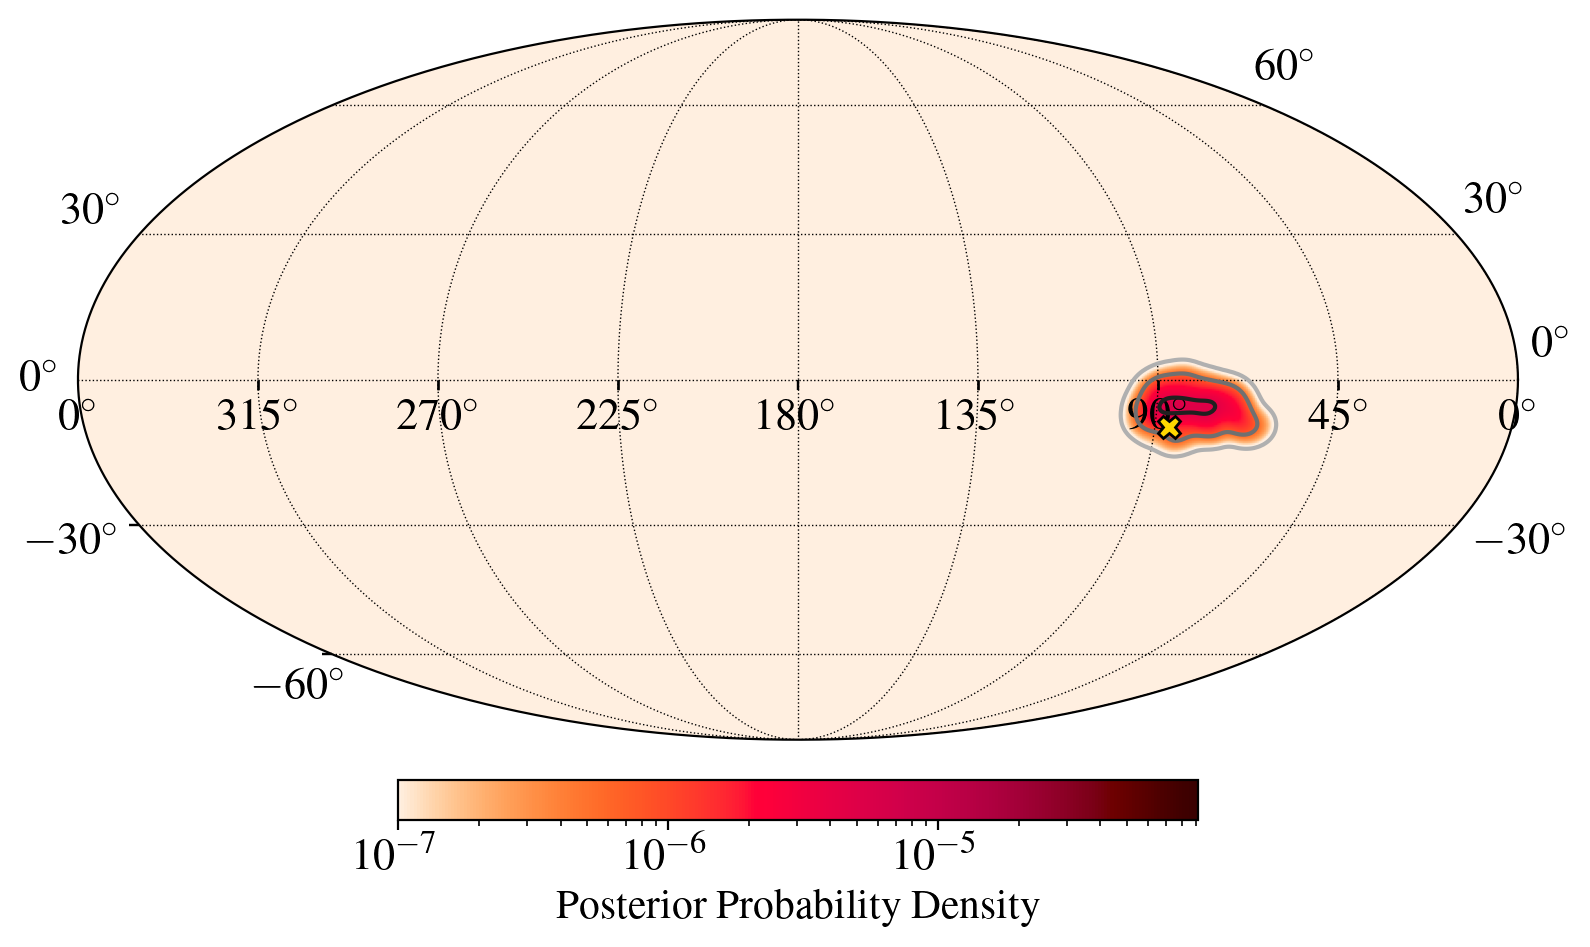

In [9]:
skymap_10, metadata_10 = io.read_sky_map("BURNIN_skymap_COMPLETELY_NEW_10hours.fits", nest=None)
nside = hp.npix2nside(len(skymap_10))

deg2perpix = hp.nside2pixarea(nside, degrees=True)
probperdeg2 = skymap_10 / deg2perpix

pix_scale = 0.1 * u.deg
smooth = 20 * pix_scale

## single colour alpha gradient cmap
cmap = plt.get_cmap('viridis', 3)  # 'viridis
colors = [cmap(i) for i in range(cmap.N)]


from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
from astropy import units as u, coordinates as coord

plt.figure(figsize=(10, 4))
ax = plt.axes([0, 0, 1, 1], projection="astro degrees mollweide")
ax.grid()

center = coord.SkyCoord(
    dec=injection_parameters[8] * u.rad,
    ra=injection_parameters[7] * u.rad
)

# Show full posterior probability gradient
image = ax.imshow_hpx(
    (skymap_10, 'ICRS'),
    nested=metadata_10['nest'],
    cmap='cylon',
    norm=LogNorm(vmin=1e-7, vmax=skymap_10.max(), clip=True),
    smooth=smooth#*1/100,
)

# Overlay the 1σ, 2σ, 3σ contours
confidence_levels = 100 * postprocess.find_greedy_credible_levels(skymap_10)
contours = ax.contour_hpx(
    (confidence_levels, 'ICRS'),
    nested=metadata_10['nest'],
    linewidth=2,
    levels=[68.27, 95.45, 99.73],
    smooth=smooth,
    colors = ['#202020', '#707070', '#B0B0B0']
)

# Mark true sky location
ax.plot_coord(center, 'X', markeredgecolor='k', color='gold', markersize=8)

# Add colorbar
cb = plt.colorbar(image, ax=ax, orientation='horizontal', pad=0.05, fraction=0.05)
cb.set_label('Posterior Probability Density', fontsize=15)

# plt.savefig(
#     "10hours_different_inputs/skymap.pdf",
#     dpi=300,
#     bbox_inches='tight',
#     pad_inches=0.1
# )
plt.show()


/opt/anaconda3/envs/lisa_env/lib/python3.12/site-packages/astropy/visualization/wcsaxes/core.py:258: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = super().contour(*args, **kwargs)


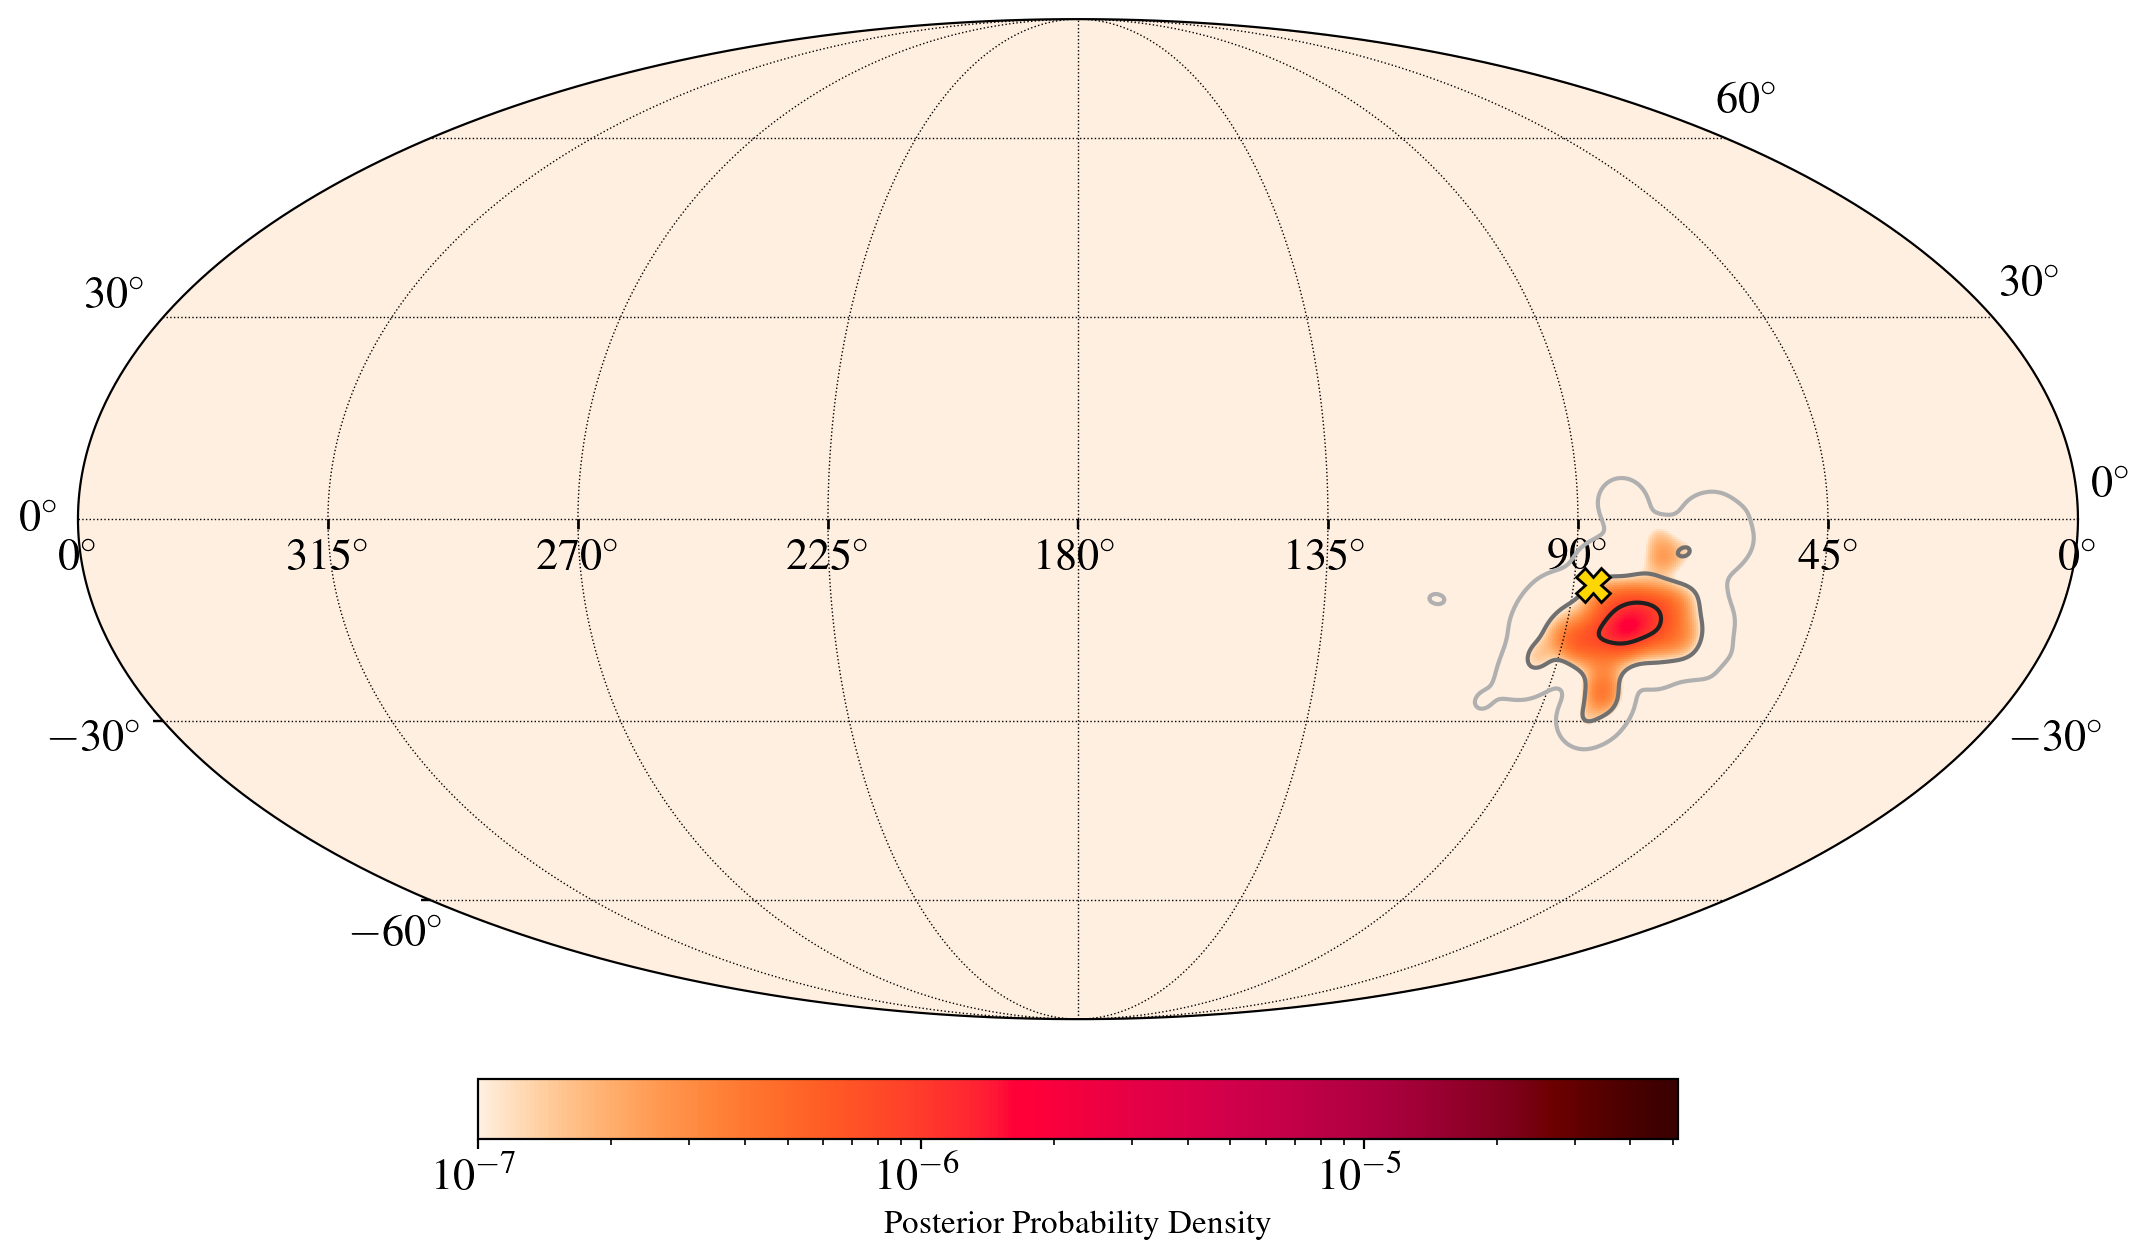

In [4]:
skymap_14, metadata_14 = io.read_sky_map("modified_skymap_COMPLETELY_NEW_14_hours.fits", nest=None)
nside = hp.npix2nside(len(skymap_14))

deg2perpix = hp.nside2pixarea(nside, degrees=True)
probperdeg2 = skymap_14 / deg2perpix
pix_scale = 0.1 * u.deg
smooth = 20 * pix_scale
## single colour alpha gradient cmap
cmap = plt.get_cmap('viridis', 3)  # 'viridis
colors = [cmap(i) for i in range(cmap.N)]

from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
from astropy import units as u, coordinates as coord

plt.figure(figsize=(10, 6))
ax = plt.axes([0, 0, 1, 1], projection="astro degrees mollweide")
ax.grid()

center = coord.SkyCoord(
    dec=injection_parameters[8] * u.rad,
    ra=injection_parameters[7] * u.rad
)

# Show full posterior probability gradient
image = ax.imshow_hpx(
    (skymap_14, 'ICRS'),
    nested=metadata_14['nest'],
    cmap='cylon',
    norm=LogNorm(vmin=1e-7, vmax=skymap_14.max(), clip=True),
    smooth=smooth#*1/100,
)

# Overlay the 1σ, 2σ, 3σ contours
confidence_levels = 100 * postprocess.find_greedy_credible_levels(skymap_14)
contours = ax.contour_hpx(
    (confidence_levels, 'ICRS'),
    nested=metadata_14['nest'],
    linewidth=2,
    levels=[68.27, 95.45, 99.73],
    smooth=smooth,
    colors = ['#202020', '#707070', '#B0B0B0']
)

# Mark true sky location
ax.plot_coord(center, 'X', markeredgecolor='k', color='gold', markersize=12)

# Add colorbar
cb = plt.colorbar(image, ax=ax, orientation='horizontal', pad=0.05, fraction=0.05)
cb.set_label('Posterior Probability Density', fontsize=12)

# plt.savefig(
#     "14hours/skymap.pdf",
#     dpi=300,
#     bbox_inches='tight',
#     pad_inches=0.1
# )
plt.show()


/opt/anaconda3/envs/lisa_env/lib/python3.12/site-packages/astropy/visualization/wcsaxes/core.py:258: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = super().contour(*args, **kwargs)


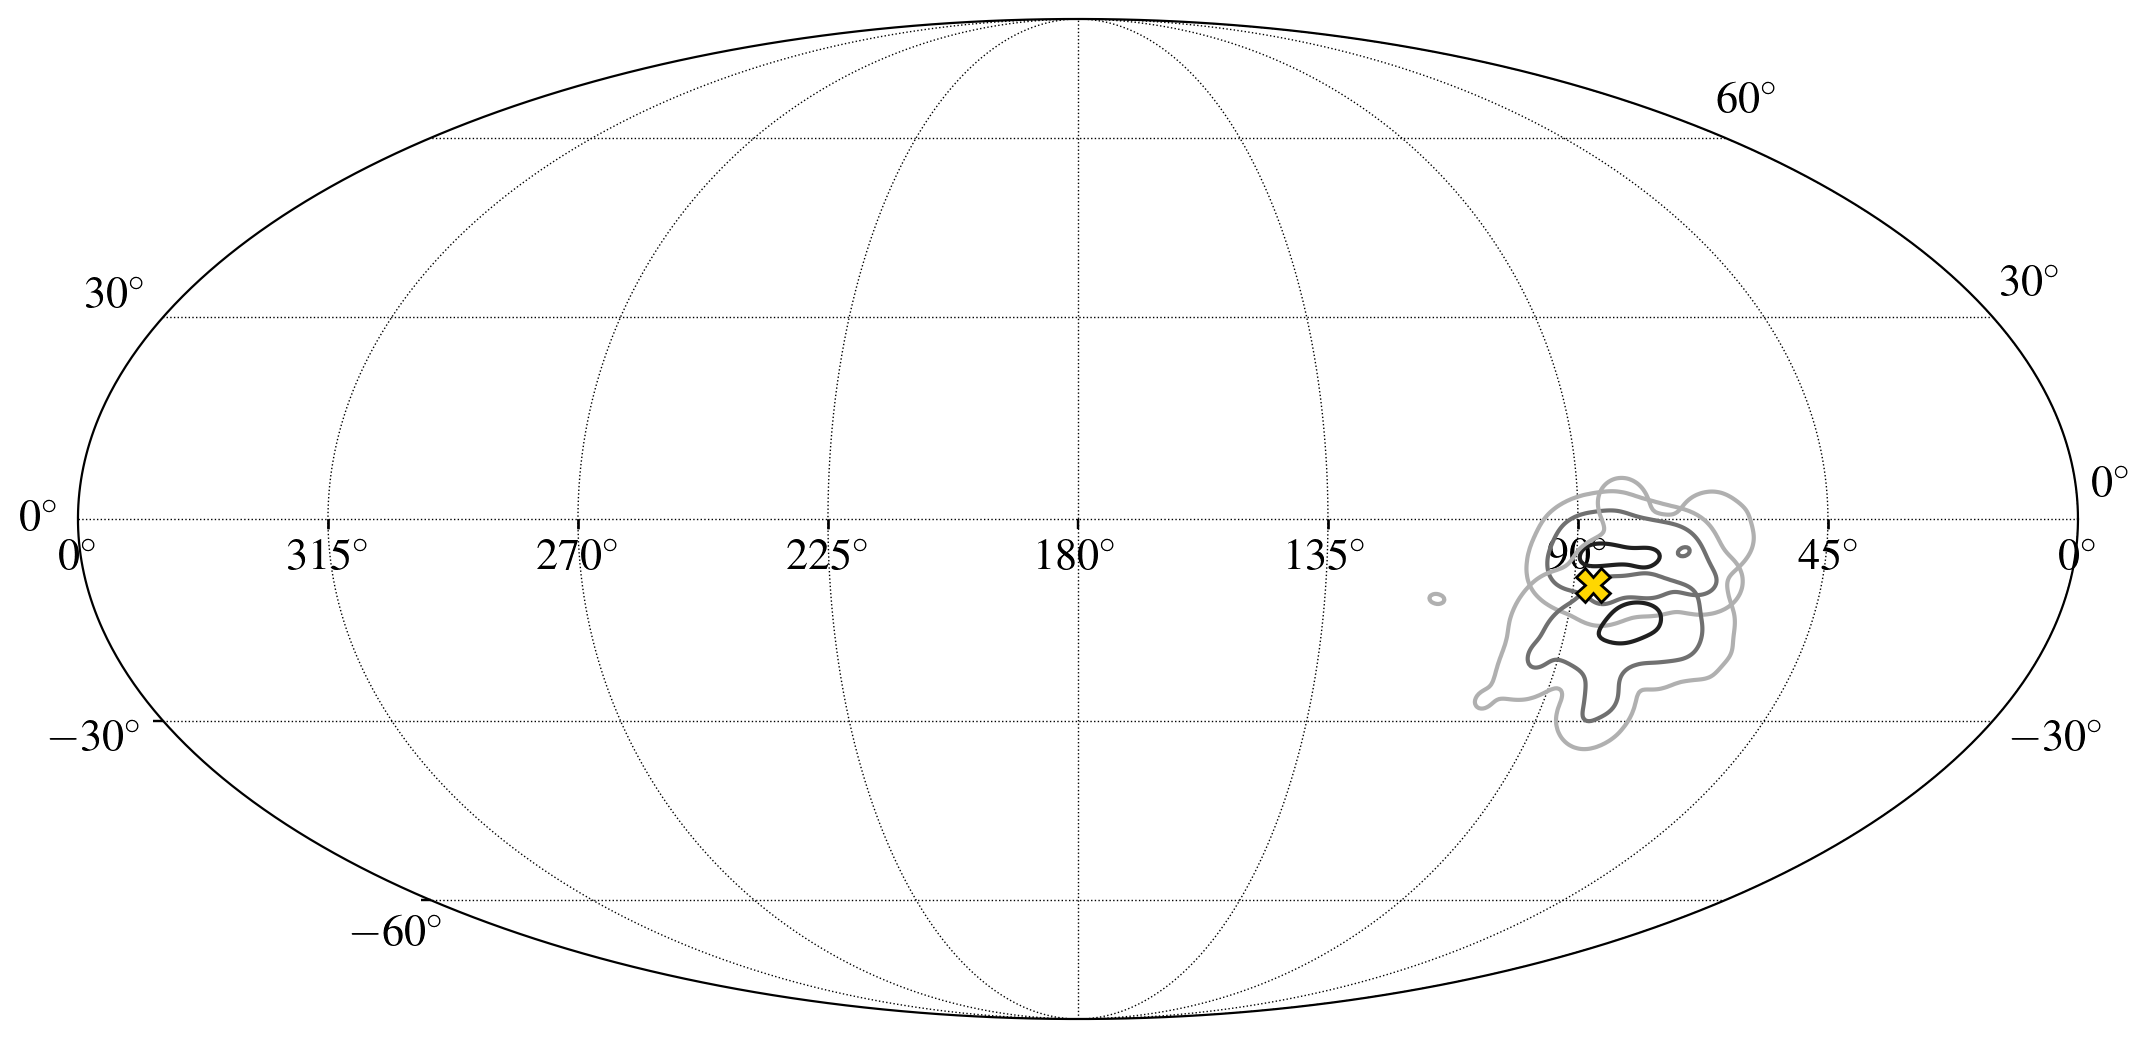

In [10]:
plt.figure(figsize=(10, 6))
ax = plt.axes([0, 0, 1, 1], projection="astro degrees mollweide")
ax.grid()

center = coord.SkyCoord(
    dec=injection_parameters[8] * u.rad,
    ra=injection_parameters[7] * u.rad
)

# Show full posterior probability gradient
# image_10 = ax.imshow_hpx(
#     (skymap_10, 'ICRS'),
#     nested=metadata_10['nest'],
#     cmap='cylon',
#     norm=LogNorm(vmin=1e-7, vmax=skymap_10.max(), clip=True),
#     smooth=smooth#*1/100,
# )

# Overlay the 1σ, 2σ, 3σ contours
confidence_levels_10 = 100 * postprocess.find_greedy_credible_levels(skymap_10)
contours_10 = ax.contour_hpx(
    (confidence_levels_10, 'ICRS'),
    nested=metadata_10['nest'],
    linewidth=2,
    levels=[68.27, 95.45, 99.73],
    smooth=smooth,
    colors = ['#202020', '#707070', '#B0B0B0']
)

# Show full posterior probability gradient
# image_14 = ax.imshow_hpx(
#     (skymap_14, 'ICRS'),
#     nested=metadata_14['nest'],
#     cmap='cylon',
#     norm=LogNorm(vmin=1e-7, vmax=skymap_14.max(), clip=True),
#     smooth=smooth#*1/100,
# )

# Overlay the 1σ, 2σ, 3σ contours
confidence_levels_14 = 100 * postprocess.find_greedy_credible_levels(skymap_14)
contours_14 = ax.contour_hpx(
    (confidence_levels_14, 'ICRS'),
    nested=metadata_14['nest'],
    linewidth=2,
    levels=[68.27, 95.45, 99.73],
    smooth=smooth,
    colors = ['#202020', '#707070', '#B0B0B0']
)

# Mark true sky location
ax.plot_coord(center, 'X', markeredgecolor='k', color='gold', markersize=12)

# Add colorbar
#cb = plt.colorbar(image_14, ax=ax, orientation='horizontal', pad=0.05, fraction=0.05)
#cb.set_label('Posterior Probability Density', fontsize=12)

# plt.savefig(
#     "14hours/skymap.pdf",
#     dpi=300,
#     bbox_inches='tight',
#     pad_inches=0.1
# )
plt.show()

/opt/anaconda3/envs/lisa_env/lib/python3.12/site-packages/astropy/visualization/wcsaxes/core.py:258: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = super().contour(*args, **kwargs)
/var/folders/zq/6x2qbk397t13zwgl047mwbkm0000gn/T/ipykernel_43751/1776661636.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0)


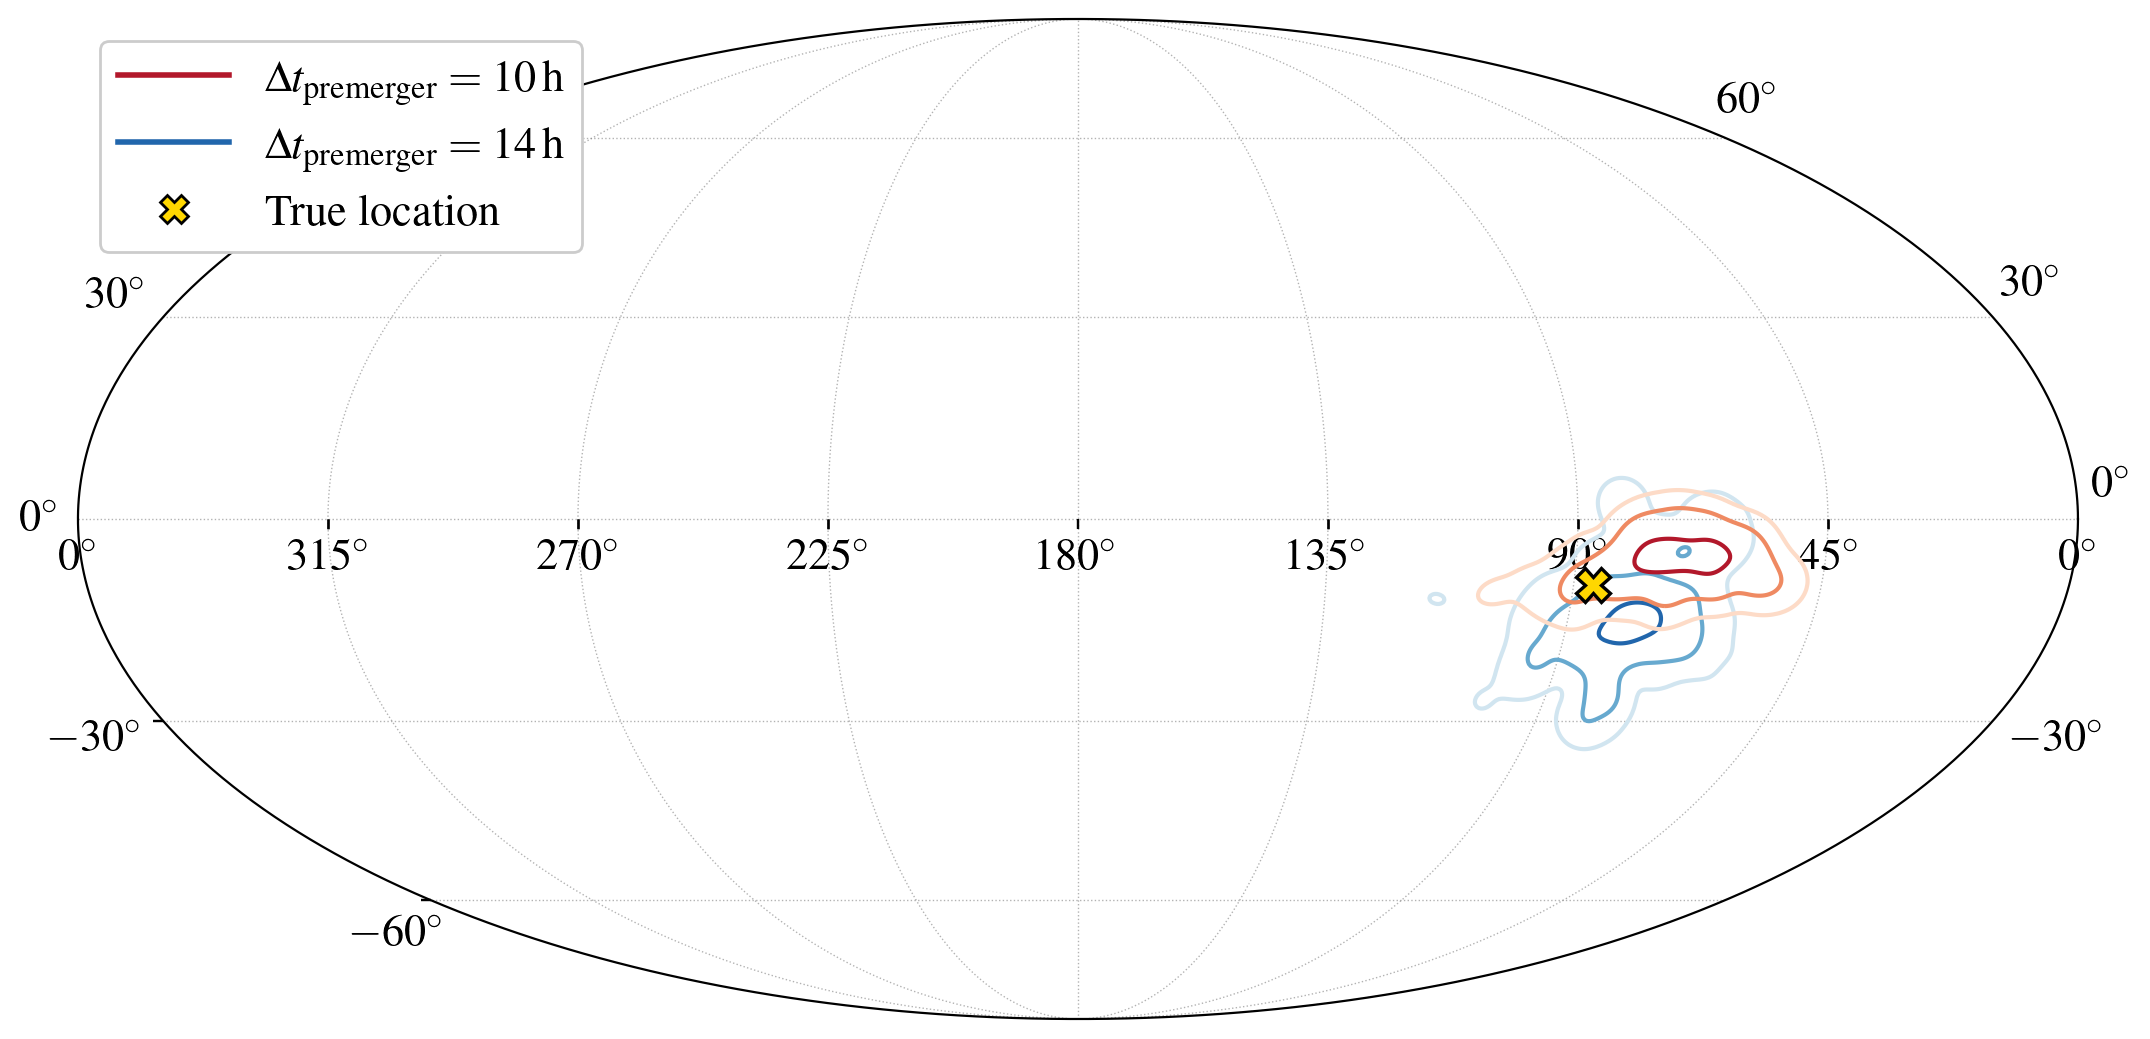

In [ ]:
# ---------------------------
#  Create figure
# ---------------------------
plt.figure(figsize=(10, 6))
ax = plt.axes([0, 0, 1, 1], projection="astro degrees mollweide")
ax.grid(color='gray', ls=':', lw=0.5, alpha=0.6)

# ---------------------------
#  True source position
# ---------------------------
center = coord.SkyCoord(
    dec=injection_parameters[8] * u.rad,
    ra=injection_parameters[7] * u.rad
)

confidence_levels_14 = 100 * postprocess.find_greedy_credible_levels(skymap_14)
ax.contourf_hpx(
    (confidence_levels_14, 'ICRS'),
    nested=metadata_14['nest'],
    levels=[0, 68.27, 95.45, 99.73, 100],
    colors=['#08306b', '#2171b5', '#6baed6', '#deebf7'],
    alpha=0.3,
    smooth=smooth
)

# Contour lines on top
ax.contour_hpx(
    (confidence_levels_14, 'ICRS'),
    nested=metadata_14['nest'],
    linewidth=1.8,
    levels=[68.27, 95.45, 99.73],
    smooth=smooth,
    colors=['#08306b', '#2171b5', '#6baed6']
)

# ---------------------------
#  Skymap 10h filled regions (red shades)
# ---------------------------
confidence_levels_10 = 100 * postprocess.find_greedy_credible_levels(skymap_10)
ax.contourf_hpx(
    (confidence_levels_10, 'ICRS'),
    nested=metadata_10['nest'],
    levels=[0, 68.27, 95.45, 99.73, 100],
    colors=['#67000d', '#cb181d', '#fb6a4a', '#fcbba1'],
    alpha=0.3,
    smooth=smooth
)

# Contour lines on top
ax.contour_hpx(
    (confidence_levels_10, 'ICRS'),
    nested=metadata_10['nest'],
    linewidth=1.8,
    levels=[68.27, 95.45, 99.73],
    smooth=smooth,
    colors=['#67000d', '#cb181d', '#fb6a4a'],
    linestyles='solid'
)


# ---------------------------
#  True sky location marker
# ---------------------------
ax.plot_coord(center, 'X', markeredgecolor='black', color='gold', markersize=12, mew=1.2, label='True Location')
# ax.text(center.ra.deg, center.dec.deg + 10, 'True Location', 
#         transform=ax.get_transform('world'),
#         color='gold', fontsize=12, ha='center', va='bottom')

# ---------------------------
#  Legend
# ---------------------------
handles = [
    plt.Line2D([], [], color='#b2182b', linestyle='solid', lw=2, label=r"$\Delta t_{\rm premerger} = 10\,\mathrm{h}$"),
    plt.Line2D([], [], color='#2166ac', linestyle='solid', lw=2, label=r"$\Delta t_{\rm premerger} = 14\,\mathrm{h}$"),
    plt.Line2D([], [], marker='X', color='gold', markeredgecolor='black', markersize=10, lw=0, label='True location')

]
ax.legend(
    handles=handles,
    loc='upper left',
    frameon=True,              # ✅ Enable the background frame
    handlelength=2.5,
    facecolor='white',         # ✅ Set background to white
    framealpha=1               # ✅ Make it fully opaque
)
# ---------------------------
#  Final layout
# ---------------------------
plt.tight_layout(pad=0)
plt.savefig(
    "NEW_10_and_14_hours_overlayed_new_colors.pdf",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.1
)
plt.show()


/opt/anaconda3/envs/lisa_env/lib/python3.12/site-packages/astropy/visualization/wcsaxes/core.py:258: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = super().contour(*args, **kwargs)
/var/folders/zq/6x2qbk397t13zwgl047mwbkm0000gn/T/ipykernel_43751/3906370462.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0)


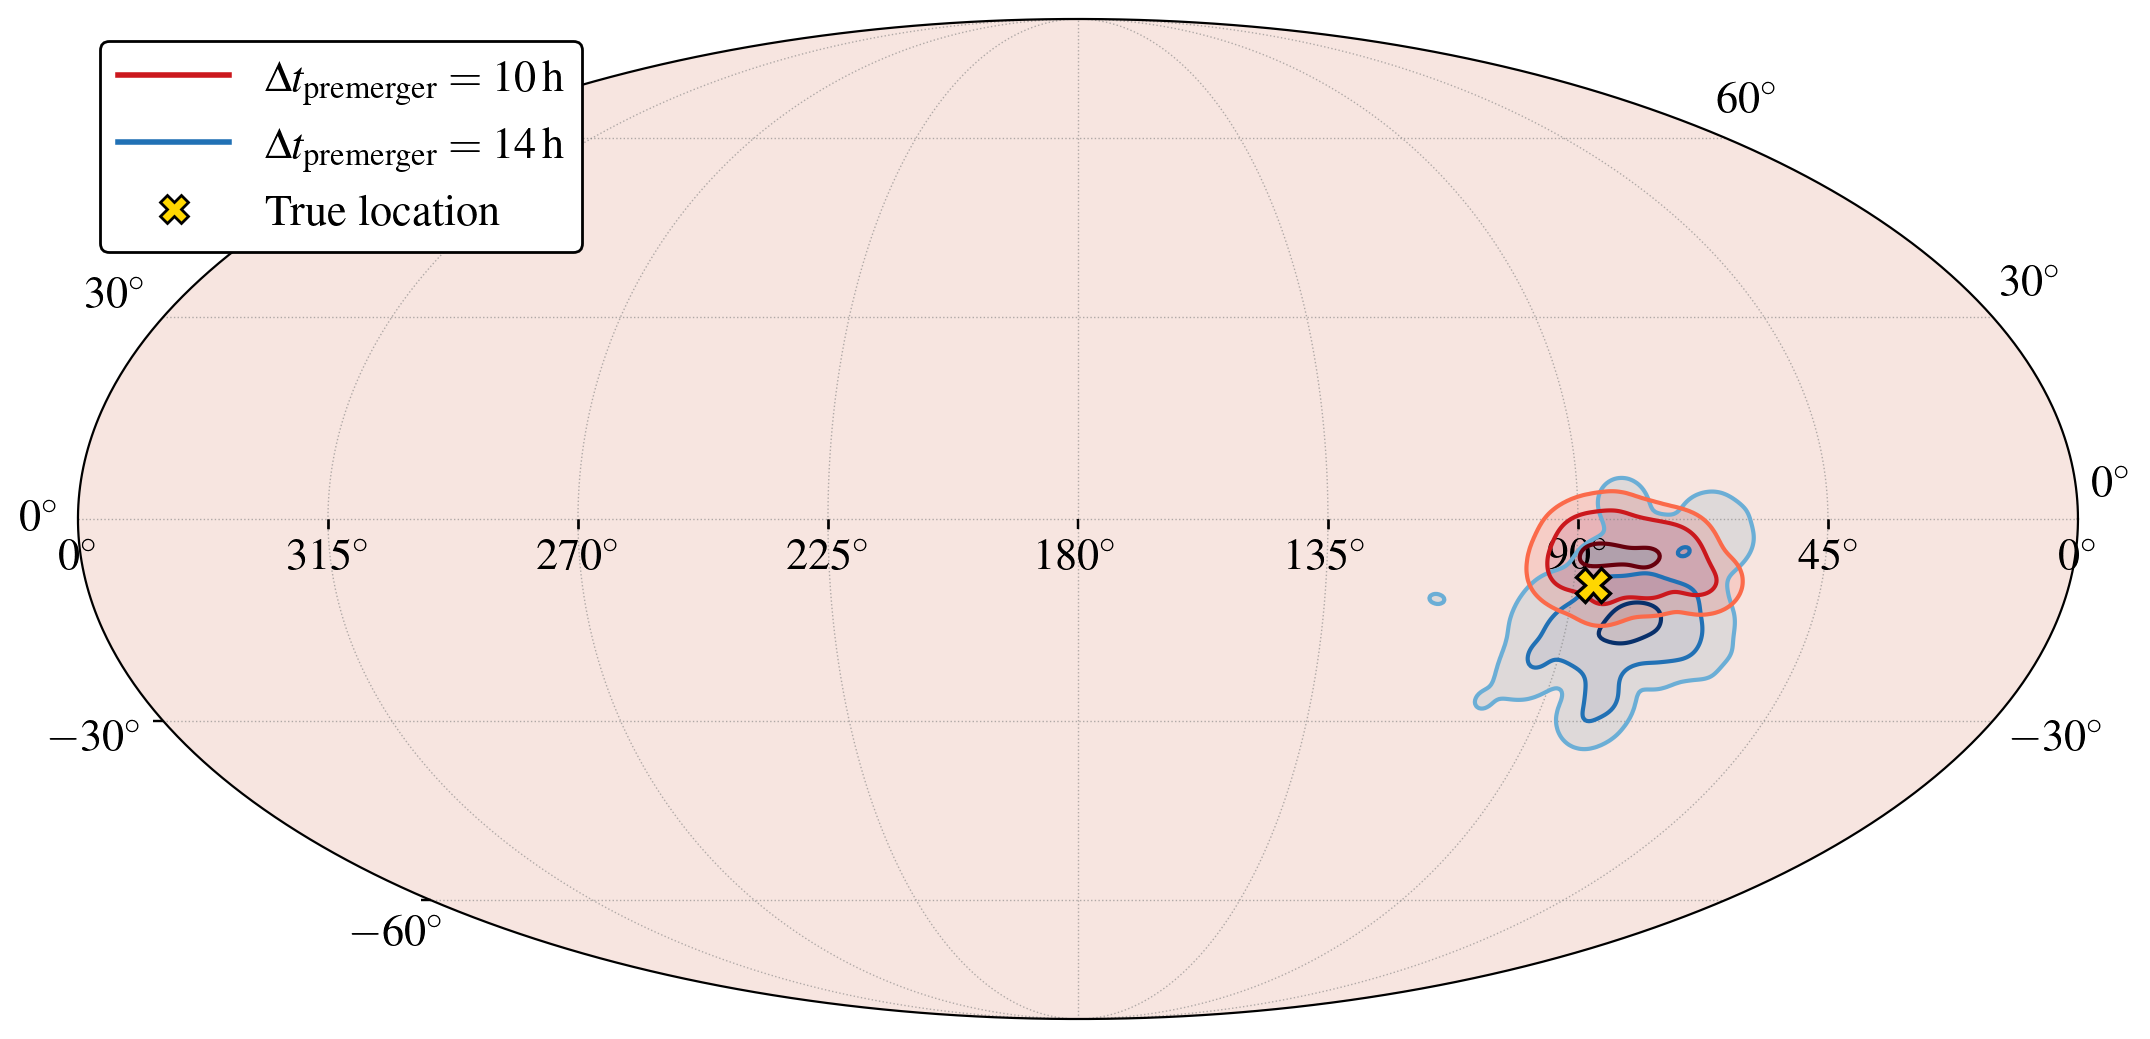

In [11]:
# ---------------------------
#  Create figure
# ---------------------------
plt.figure(figsize=(10, 6))
ax = plt.axes([0, 0, 1, 1], projection="astro degrees mollweide")
ax.grid(color='gray', ls=':', lw=0.5, alpha=0.6)

# ---------------------------
#  True source position
# ---------------------------
center = coord.SkyCoord(
    dec=injection_parameters[8] * u.rad,
    ra=injection_parameters[7] * u.rad
)

# ---------------------------
#  Skymap 14h filled regions (blue shades)
# ---------------------------
confidence_levels_14 = 100 * postprocess.find_greedy_credible_levels(skymap_14)
ax.contourf_hpx(
    (confidence_levels_14, 'ICRS'),
    nested=metadata_14['nest'],
    levels=[0, 68.27, 95.45, 99.73, 100],
    colors=['#08306b', '#2171b5', '#6baed6', '#deebf7'],
    alpha=0.3,
    smooth=smooth
)

# Contour lines on top
ax.contour_hpx(
    (confidence_levels_14, 'ICRS'),
    nested=metadata_14['nest'],
    linewidth=1.8,
    levels=[68.27, 95.45, 99.73],
    smooth=smooth,
    colors=['#08306b', '#2171b5', '#6baed6']
)

# ---------------------------
#  Skymap 10h filled regions (red shades)
# ---------------------------
confidence_levels_10 = 100 * postprocess.find_greedy_credible_levels(skymap_10)
ax.contourf_hpx(
    (confidence_levels_10, 'ICRS'),
    nested=metadata_10['nest'],
    levels=[0, 68.27, 95.45, 99.73, 100],
    colors=['#67000d', '#cb181d', '#fb6a4a', '#fcbba1'],
    alpha=0.3,
    smooth=smooth
)

# Contour lines on top
ax.contour_hpx(
    (confidence_levels_10, 'ICRS'),
    nested=metadata_10['nest'],
    linewidth=1.8,
    levels=[68.27, 95.45, 99.73],
    smooth=smooth,
    colors=['#67000d', '#cb181d', '#fb6a4a'],
    linestyles='solid'
)

# ---------------------------
#  True sky location marker
# ---------------------------
ax.plot_coord(center, 'X', markeredgecolor='black', color='gold', markersize=12, mew=1.2, label='True Location')

# ---------------------------
#  Legend
# ---------------------------
handles = [
    plt.Line2D([], [], color='#cb181d', linestyle='solid', lw=2, label=r"$\Delta t_{\rm premerger} = 10\,\mathrm{h}$"),
    plt.Line2D([], [], color='#2171b5', linestyle='solid', lw=2, label=r"$\Delta t_{\rm premerger} = 14\,\mathrm{h}$"),
    plt.Line2D([], [], marker='X', color='gold', markeredgecolor='black', markersize=10, lw=0, label='True location')
]

ax.legend(
    handles=handles,
    loc='upper left',
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=1.0,
    handlelength=2.5
)

# ---------------------------
#  Final layout
# ---------------------------
plt.tight_layout(pad=0)
plt.savefig(
    "NEW_10_and_14_hours_overlayed_new_colors.pdf",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.1
)
plt.show()
